In [2]:
import pandas as pd
import os
from google.cloud import bigquery

# Configura as credenciais
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials.json"

# Cria o cliente
client = bigquery.Client(project="gen-lang-client-0861123700")

print("Cliente BigQuery configurado!")

Cliente BigQuery configurado!


In [3]:
from google.cloud import bigquery

client = bigquery.Client(project="gen-lang-client-0861123700")

# descobrir qual tabela tem os dados de chuva
query_explorar = """
SELECT table_name
FROM `datario.clima_pluviometro.INFORMATION_SCHEMA.TABLES`
"""

print("Tabelas disponíveis no dataset de clima:")
df_tabelas = client.query(query_explorar).to_dataframe()
print(df_tabelas)

Tabelas disponíveis no dataset de clima:
                         table_name
0                estacoes_alertario
1                estacoes_websirene
2  taxa_precipitacao_alertario_5min
3       taxa_precipitacao_websirene
4                     estacoes_inea
5                  estacoes_cemaden
6            taxa_precipitacao_inea
7       taxa_precipitacao_alertario
8         taxa_precipitacao_cemaden


In [4]:
query_estrutura = """
SELECT *
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
LIMIT 5
"""

print("Buscando amostra dos dados de chuva...")
df_amostra = client.query(query_estrutura).to_dataframe()

print("Colunas disponíveis:")
print(df_amostra.columns.tolist())
print("\nAmostra dos dados:")
print(df_amostra.head())

Buscando amostra dos dados de chuva...
Colunas disponíveis:
['primary_key', 'id_estacao', 'acumulado_chuva_15_min', 'acumulado_chuva_1_h', 'acumulado_chuva_4_h', 'acumulado_chuva_24_h', 'acumulado_chuva_96_h', 'horario', 'data_particao']

Amostra dos dados:
             primary_key id_estacao  acumulado_chuva_15_min  \
0  1_2004-06-01 00:03:20          1                     0.2   
1  1_2004-06-01 01:03:20          1                     0.0   
2  1_2004-06-01 02:03:20          1                     0.0   
3  1_2004-06-01 03:03:20          1                     0.0   
4  1_2004-06-01 04:03:20          1                     0.0   

   acumulado_chuva_1_h  acumulado_chuva_4_h  acumulado_chuva_24_h  \
0                  0.2                  1.4                   3.4   
1                  0.8                  2.2                   4.2   
2                  0.0                  2.2                   4.2   
3                  0.0                  1.0                   4.2   
4                 

In [5]:
query_estacoes = """
SELECT DISTINCT id_estacao
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
ORDER BY id_estacao
"""

print("Buscando lista de estações...")
df_estacoes = client.query(query_estacoes).to_dataframe()

print(f"Total de estações: {len(df_estacoes)}")
print("\nIDs das estações:")
print(df_estacoes["id_estacao"].tolist())

Buscando lista de estações...
Total de estações: 33

IDs das estações:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '4', '5', '6', '7', '8', '9']


In [6]:
query_nomes = """
SELECT id_estacao, estacao AS nome
FROM `datario.clima_pluviometro.estacoes_alertario`
ORDER BY id_estacao
"""

print("Buscando nomes das estações...")
df_nomes_estacoes = client.query(query_nomes).to_dataframe()

print(f"{len(df_nomes_estacoes)} estações com nomes:")
print(df_nomes_estacoes)

Buscando nomes das estações...
37 estações com nomes:
   id_estacao                nome
0           1             Vidigal
1          10           Madureira
2          11               Iraja
3          12               Bangu
4          13             Piedade
5          14              Tanque
6          15               Saude
7          16     Jardim botanico
8          17            Barrinha
9          18      Cidade de deus
10         19           Riocentro
11          2                Urca
12         20           Guaratiba
13         21  Grajau jacarepagua
14         22          Santa cruz
15         23        Grande meier
16         24            Anchieta
17         25         Grota funda
18         26        Campo grande
19         27            Sepetiba
20         28   Alto da boa vista
21         29  Av brasil mendanha
22          3             Rocinha
23         30             Recreio
24         31         Laranjeiras
25         32       Sao cristovao
26         33         Tijuca

In [7]:
query_chuva = """
SELECT
    id_estacao,
    DATETIME(CONCAT(data_particao, ' ', horario)) AS timestamp,
    acumulado_chuva_15_min,
    acumulado_chuva_1_h,
    acumulado_chuva_4_h,
    acumulado_chuva_24_h,
    acumulado_chuva_96_h,
    data_particao AS data
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
WHERE data_particao BETWEEN '2010-01-01' AND '2026-12-31'
ORDER BY data_particao, horario, id_estacao
"""

print("Baixando dados de chuva 2010-2026...")
df_chuva = client.query(query_chuva).to_dataframe()

print(f"\nConcluído!")
print(f"Total de registros: {len(df_chuva):,}")
print(f"Período: {df_chuva['data'].min()} a {df_chuva['data'].max()}")
print(f"\nAmostra:")
print(df_chuva.head(10))

Baixando dados de chuva 2010-2026...

Concluído!
Total de registros: 16,876,021
Período: 2010-01-01 a 2024-06-03

Amostra:
  id_estacao           timestamp  acumulado_chuva_15_min  acumulado_chuva_1_h  \
0         32 2010-01-01 00:00:00                     0.0                  0.0   
1          8 2010-01-01 00:00:00                     0.0                  0.0   
2          4 2010-01-01 00:00:20                     0.0                  0.0   
3          5 2010-01-01 00:00:40                     0.0                  0.0   
4         13 2010-01-01 00:01:00                     0.0                  0.0   
5         15 2010-01-01 00:01:20                     0.0                  0.0   
6          7 2010-01-01 00:01:40                     0.0                  0.0   
7         23 2010-01-01 00:02:00                     0.0                  0.0   
8          9 2010-01-01 00:02:20                     0.0                  0.0   
9         10 2010-01-01 00:02:40                     0.0           

In [8]:
# Converte id_estacao para string para fazer o merge
df_chuva["id_estacao"] = df_chuva["id_estacao"].astype(str)
df_nomes_estacoes["id_estacao"] = df_nomes_estacoes["id_estacao"].astype(str)

# Faz o merge
df_chuva = df_chuva.merge(df_nomes_estacoes, on="id_estacao", how="left")

# Padroniza nome da estação
df_chuva["nome"] = (
    df_chuva["nome"]
    .str.strip()
    .str.upper()
    .str.normalize("NFC")
)

# Converte timestamp para datetime
df_chuva["timestamp"] = pd.to_datetime(df_chuva["timestamp"])
df_chuva["data"] = pd.to_datetime(df_chuva["data"])

# Cria colunas auxiliares
df_chuva["ano"] = df_chuva["data"].dt.year
df_chuva["mes"] = df_chuva["data"].dt.month

print("Dados tratados!")
print(f"\nEstações com mais registros:")
print(df_chuva["nome"].value_counts().head(10))
print(f"\nDistribuição por ano:")
print(df_chuva.groupby("ano").size())

Dados tratados!

Estações com mais registros:
nome
LARANJEIRAS    518566
ROCINHA        518518
SANTA CRUZ     518408
GROTA FUNDA    518399
IRAJA          517751
TIJUCA         517545
RIOCENTRO      516829
VIDIGAL        516815
PIEDADE        516797
ANCHIETA       516795
Name: count, dtype: int64

Distribuição por ano:
ano
2010    1054689
2011    1117550
2012    1119025
2013    1154889
2014    1156188
2015    1156188
2016    1159356
2017    1156188
2018    1156228
2019    1156240
2020    1159486
2021    1156319
2022    1108757
2023     984944
2024    1079974
dtype: int64


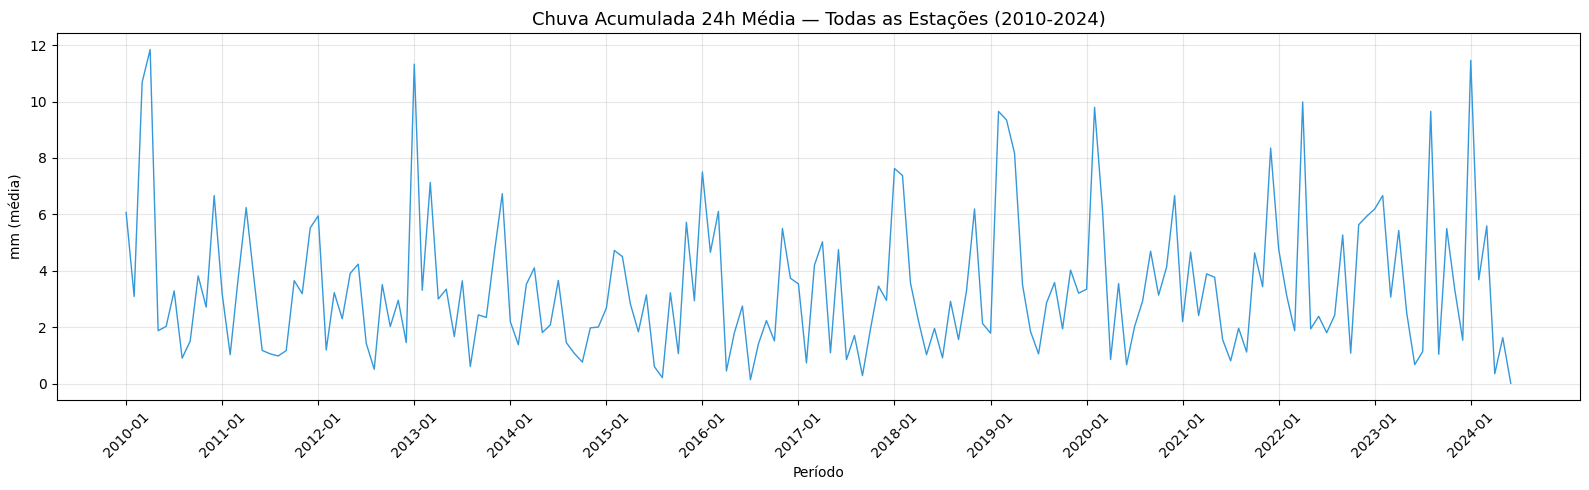

Gráfico salvo

Arquivo salvo com sucesso!
   Caminho: ../data/processed/chuva_alertario.parquet
   Linhas: 16,876,021
   Colunas: ['id_estacao', 'timestamp', 'acumulado_chuva_15_min', 'acumulado_chuva_1_h', 'acumulado_chuva_4_h', 'acumulado_chuva_24_h', 'acumulado_chuva_96_h', 'data', 'nome', 'ano', 'mes']


In [9]:
import matplotlib.pyplot as plt

# Cria a pasta se não existir
os.makedirs("../figuras", exist_ok=True)

# Gráfico: Chuva acumulada 24h média por mês (todas as estações)
chuva_mensal = df_chuva.groupby(["ano", "mes"])["acumulado_chuva_24_h"].mean().reset_index()
chuva_mensal["ano_mes"] = chuva_mensal["ano"].astype(str) + "-" + chuva_mensal["mes"].astype(str).str.zfill(2)

plt.figure(figsize=(16, 5))
plt.plot(range(len(chuva_mensal)), chuva_mensal["acumulado_chuva_24_h"], color="#3498DB", linewidth=1)
plt.title("Chuva Acumulada 24h Média — Todas as Estações (2010-2024)", fontsize=13)
plt.xlabel("Período")
plt.ylabel("mm (média)")
plt.xticks(range(0, len(chuva_mensal), 12), chuva_mensal["ano_mes"][::12], rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figuras/chuva_temporal.png", dpi=150)
plt.show()
print("Gráfico salvo")

# Salvar parquet
os.makedirs("../data/processed", exist_ok=True)
caminho = "../data/processed/chuva_alertario.parquet"

df_chuva.to_parquet(caminho, index=False)

df_teste = pd.read_parquet(caminho)
print(f"\nArquivo salvo com sucesso!")
print(f"   Caminho: {caminho}")
print(f"   Linhas: {len(df_teste):,}")
print(f"   Colunas: {df_teste.columns.tolist()}")